In [1]:
# check if 

import numpy as np
import xarray as xr
import pandas as pd
import copy
from datetime import datetime, timedelta
# import visualkeras
# import tensorflow as tf
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from scipy.stats import chi2_contingency

from sklearn.utils.class_weight import compute_class_weight
import sys
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import glob
import sys
import string

sys.path.append("/glade/u/home/jhayron/WR_Predictability/3_MLModels/")

In [2]:
wr_series = pd.read_csv('/glade/work/jhayron/Data4Predictability/WR_Series_20231120.csv',\
                index_col=0,names=['week0'],skiprows=1,parse_dates=True)
for wk in range(2,10):
    series_temp = copy.deepcopy(wr_series["week0"])
    series_temp.index = series_temp.index - timedelta(weeks = wk-1)
    series_temp.name = f'week{wk-1}'
    if wk==2:
        df_shifts = pd.concat([pd.DataFrame(wr_series["week0"]),pd.DataFrame(series_temp)],axis=1)  
    else:
        df_shifts = pd.concat([df_shifts,pd.DataFrame(series_temp)],axis=1)

In [3]:
path_results = 'results/'

In [4]:
list_folders = np.sort(glob.glob('/glade/u/home/jhayron/WR_Predictability/6_PCA_xgboost/figures_detrended_20240317/*/'))
list_vars = [list_folders[i].split('/')[-2] for i in range(len(list_folders))]

for ivar,var in enumerate(list_vars):
    print(ivar,var)

0 IC_SODA
1 IT_SODA
2 MLD_SODA
3 OHC100_SODA
4 OHC200_SODA
5 OHC300_SODA
6 OHC50_SODA
7 OHC700_SODA
8 OLR_ERA5
9 SD_ERA5
10 SSH_SODA
11 SST_OISSTv2
12 SST_SODA
13 STL_1m_ERA5
14 STL_28cm_ERA5
15 STL_7cm_ERA5
16 STL_full_ERA5
17 SWVL_1m_ERA5
18 SWVL_28cm_ERA5
19 SWVL_7cm_ERA5
20 SWVL_full_ERA5
21 U10_ERA5
22 U200_ERA5
23 Z500_ERA5
24 Z500_ERA5_Region


In [5]:
indices_atmosphere = np.array([8, 21, 22, 23])
indices_land = np.array([9, 13, 14, 15, 16, 17, 18, 19, 20])
# indices_land = np.array([9,12,13,14,15,16,18,19])
indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])
# indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])

# Analysis of correct cases with all data

In [6]:
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

In [7]:
# all_accs = []
# weeks = np.arange(1,9)
# for ivar in range(len(list_vars)-1):
#     try:
#         orig_stdout = sys.stdout
#         name_temp = list_vars[ivar]
        
#         f = open(f'results_pca_f1_analysis/{name_temp}.txt', 'w')
#         sys.stdout = f
        
#         print(f'********************{name_temp}********************')
#         acc_temp = []
#         for week in weeks:
#             print(f'*******{week}*******')
#             results_temp = pd.read_csv(f'{path_results}results_{name_temp}_week{week}.csv',
#                                       index_col=0,parse_dates=True)
#             acc_temp.append(f1_score(results_temp['y_true'],results_temp['y_predicted'],average='macro'))
#             print(f'-- f1_score: {acc_temp[-1]}')
#             correct_indices = np.where(results_temp['y_true']==results_temp['y_predicted'])[0]
#             n_correct_predictions = len(correct_indices)
#             counts_wr_correct = results_temp.iloc[correct_indices,0].value_counts()
#             df_correct = results_temp.iloc[correct_indices,0]
            
#             print('-- Number and percentage of correct counts corresponding to each WR')
#             print(counts_wr_correct,counts_wr_correct/np.sum(counts_wr_correct))
            
#             print('-- Number and percentage of correct counts corresponding to each season')
#             for season in indices_seasons.keys():
#                 df_season = df_correct[(df_correct.index.month==indices_seasons[season][0])|\
#                                         (df_correct.index.month==indices_seasons[season][1])|\
#                                         (df_correct.index.month==indices_seasons[season][2])]
#                 print(season,len(df_season),len(df_season)*100/len(df_correct))
            
#             pcas = pd.read_csv(f'../figures_detrended_20/{name_temp}/PC_{name_temp}.csv',
#                       index_col=0, parse_dates=True)
#             print('-- Five most anomalous PCs')
#             # norm_pcas = pcas/np.max(abs(pcas),axis=0)
    
#             # print(norm_pcas.loc[df_correct.index].abs().mean(axis=0).sort_values(ascending=False)[:5])
#             print(pcas.loc[df_correct.index].abs().mean(axis=0).sort_values(ascending=False)[:5])
#             # print((100*(pcas.loc[df_correct.index].abs().mean(axis=0) - pcas.abs().mean(axis=0))\
#             #     /pcas.abs().mean(axis=0)).sort_values(ascending=False)[:5])
#         sys.stdout = orig_stdout
#         f.close()    
#     except: pass

# Heat maps

In [8]:
# I want an array with number of variables in the y axis, principal components in the x axis, and the value being the average 
# anomaly of the PC when accurate predictions are done

In [9]:
indices_atmosphere = np.array([8, 21, 22, 23])
indices_land = np.array([9, 13, 14, 15, 16, 17, 18, 19, 20])
# indices_land = np.array([9,12,13,14,15,16,18,19])
indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])
# indices_ocean = np.array([0, 1, 2, 3, 4, 5, 6, 7, 10, 12])

In [10]:
indices_ordered = [23,8,21,22, 0, 1, 2, 3, 4, 5, 6, 7, 10, 12, 9, 13, 14, 15, 16, 17, 18, 19, 20] # atmosphere ocean land
weeks = np.arange(1,9)

In [11]:
ivar

24

In [12]:
pc_mean_when_accurate = {}
for week in weeks:
# for week in [1]:
    pc_when_accurate_week = []
    for ivar in indices_ordered:
        name_temp = list_vars[ivar]
        results_temp = pd.read_csv(f'{path_results}results_{name_temp}_week{week}.csv',
                                  index_col=0,parse_dates=True)
        pcas = pd.read_csv(f'../figures_detrended_20240317/{name_temp}/PC_{name_temp}.csv',
                  index_col=0, parse_dates=True)
        
        correct_indices = np.where(results_temp['y_true']==results_temp['y_predicted'])[0]
        df_correct = results_temp.iloc[correct_indices,0]
        acc_temp = len(correct_indices) / len(results_temp)
        
        pc_mag_all = pcas.abs().mean(axis=0).values
        pc_mag_correct = pcas.loc[df_correct.index].abs().mean(axis=0).values
        mag_change = pc_mag_correct - pc_mag_all
        mag_change_percentage = (100 * mag_change / pc_mag_all)# * acc_temp
        # norm_perc_change = mag_change_percentage * acc_temp
        pc_when_accurate_week.append(mag_change_percentage)
        # aaaa
    pc_mean_when_accurate[week] = np.array(pc_when_accurate_week)
    # pc_mean_when_accurate[week][pc_mean_when_accurate[week]<0] = np.nan
    # aaa
        

In [13]:
# for week in weeks:
#     plt.pcolormesh(np.arange(0,20),np.array(list_vars)[indices_ordered],
#                    pc_mean_when_accurate[week],vmin = -7, vmax= 7,cmap='coolwarm')
#     plt.xticks(np.arange(0,20))
#     plt.title(week)
#     plt.colorbar()
#     plt.show()
#     plt.close('all')

# Compute significance

In [14]:
df_wr_temp = df_shifts['week0'].dropna()
mean_hist_wrs = np.histogram(df_wr_temp,bins=np.arange(-0.5,5,1))[0]
mean_hist_wrs = mean_hist_wrs/np.sum(mean_hist_wrs)

In [15]:
significance_pcs = {}
for week in weeks:
    # print(week)
    significance_pcs_week = []
    for ivar in indices_ordered:
        name_temp = list_vars[ivar]
        # print(name_temp)
        results_temp = pd.read_csv(f'{path_results}results_{name_temp}_week{week}.csv',
                                  index_col=0,parse_dates=True)
        pcas = pd.read_csv(f'../figures_detrended_20240317/{name_temp}/PC_{name_temp}.csv',
                  index_col=0, parse_dates=True)
        
        significance_pcs_week_var = []
        for ipc in range(len(pcas.keys())):
            # print(ipc)
            df_wr_temp = df_shifts[f'week{week}']
            pca_temp = pcas[f'{ipc}']
            perc_20 = np.percentile(pca_temp,20)
            perc_80 = np.percentile(pca_temp,80)
            df_pc_wr = pd.concat([pca_temp,df_shifts[f'week{week}']],axis=1).dropna()

            ## High values
            df_temp = df_pc_wr[(df_pc_wr[str(ipc)]>=perc_80)][f'week{week}']
            # hist_temp = np.histogram(df_temp,bins=np.arange(-0.5,5,1))[0]
            # hist_temp = hist_temp/np.sum(hist_temp)
            freq_table_A = df_wr_temp.value_counts().sort_index()##
            freq_table_B = df_temp.value_counts().sort_index()##
            observed = pd.concat([freq_table_A, freq_table_B], axis=1).fillna(0).values##
            _, p80, _, _ = chi2_contingency(observed)##
            
            ## Low values
            df_temp = df_pc_wr[(df_pc_wr[str(ipc)]<=perc_20)][f'week{week}']
            # hist_temp = np.histogram(df_temp,bins=np.arange(-0.5,5,1))[0]
            # hist_temp = hist_temp/np.sum(hist_temp)
            freq_table_A = df_wr_temp.value_counts().sort_index()##
            freq_table_B = df_temp.value_counts().sort_index()##
            observed = pd.concat([freq_table_A, freq_table_B], axis=1).fillna(0).values##
            _, p20, _, _ = chi2_contingency(observed)##
            # print (p20)
            if (p20<0.05)|(p80<0.05):
                significance_pcs_week_var.append(1)
            else:
                significance_pcs_week_var.append(0)
        significance_pcs_week.append(significance_pcs_week_var)
    significance_pcs[week] = np.array(significance_pcs_week)
    # aa

In [16]:
# for week in weeks:
#     plt.pcolormesh(np.arange(0,20),np.array(list_vars)[indices_ordered],
#                    significance_pcs[week],vmin = 0, vmax= 1,cmap='coolwarm')
#     plt.xticks(np.arange(0,20))
#     plt.title(week)
#     plt.colorbar()
#     plt.show()
#     plt.close('all')

In [17]:
significance_filtered = {}
for week in weeks:
    significance_filtered[week] = copy.deepcopy(significance_pcs[week])
    significance_filtered[week][np.isfinite(pc_mean_when_accurate[week])==False] = 0
    significance_filtered[week][pc_mean_when_accurate[week]<=0] = 0

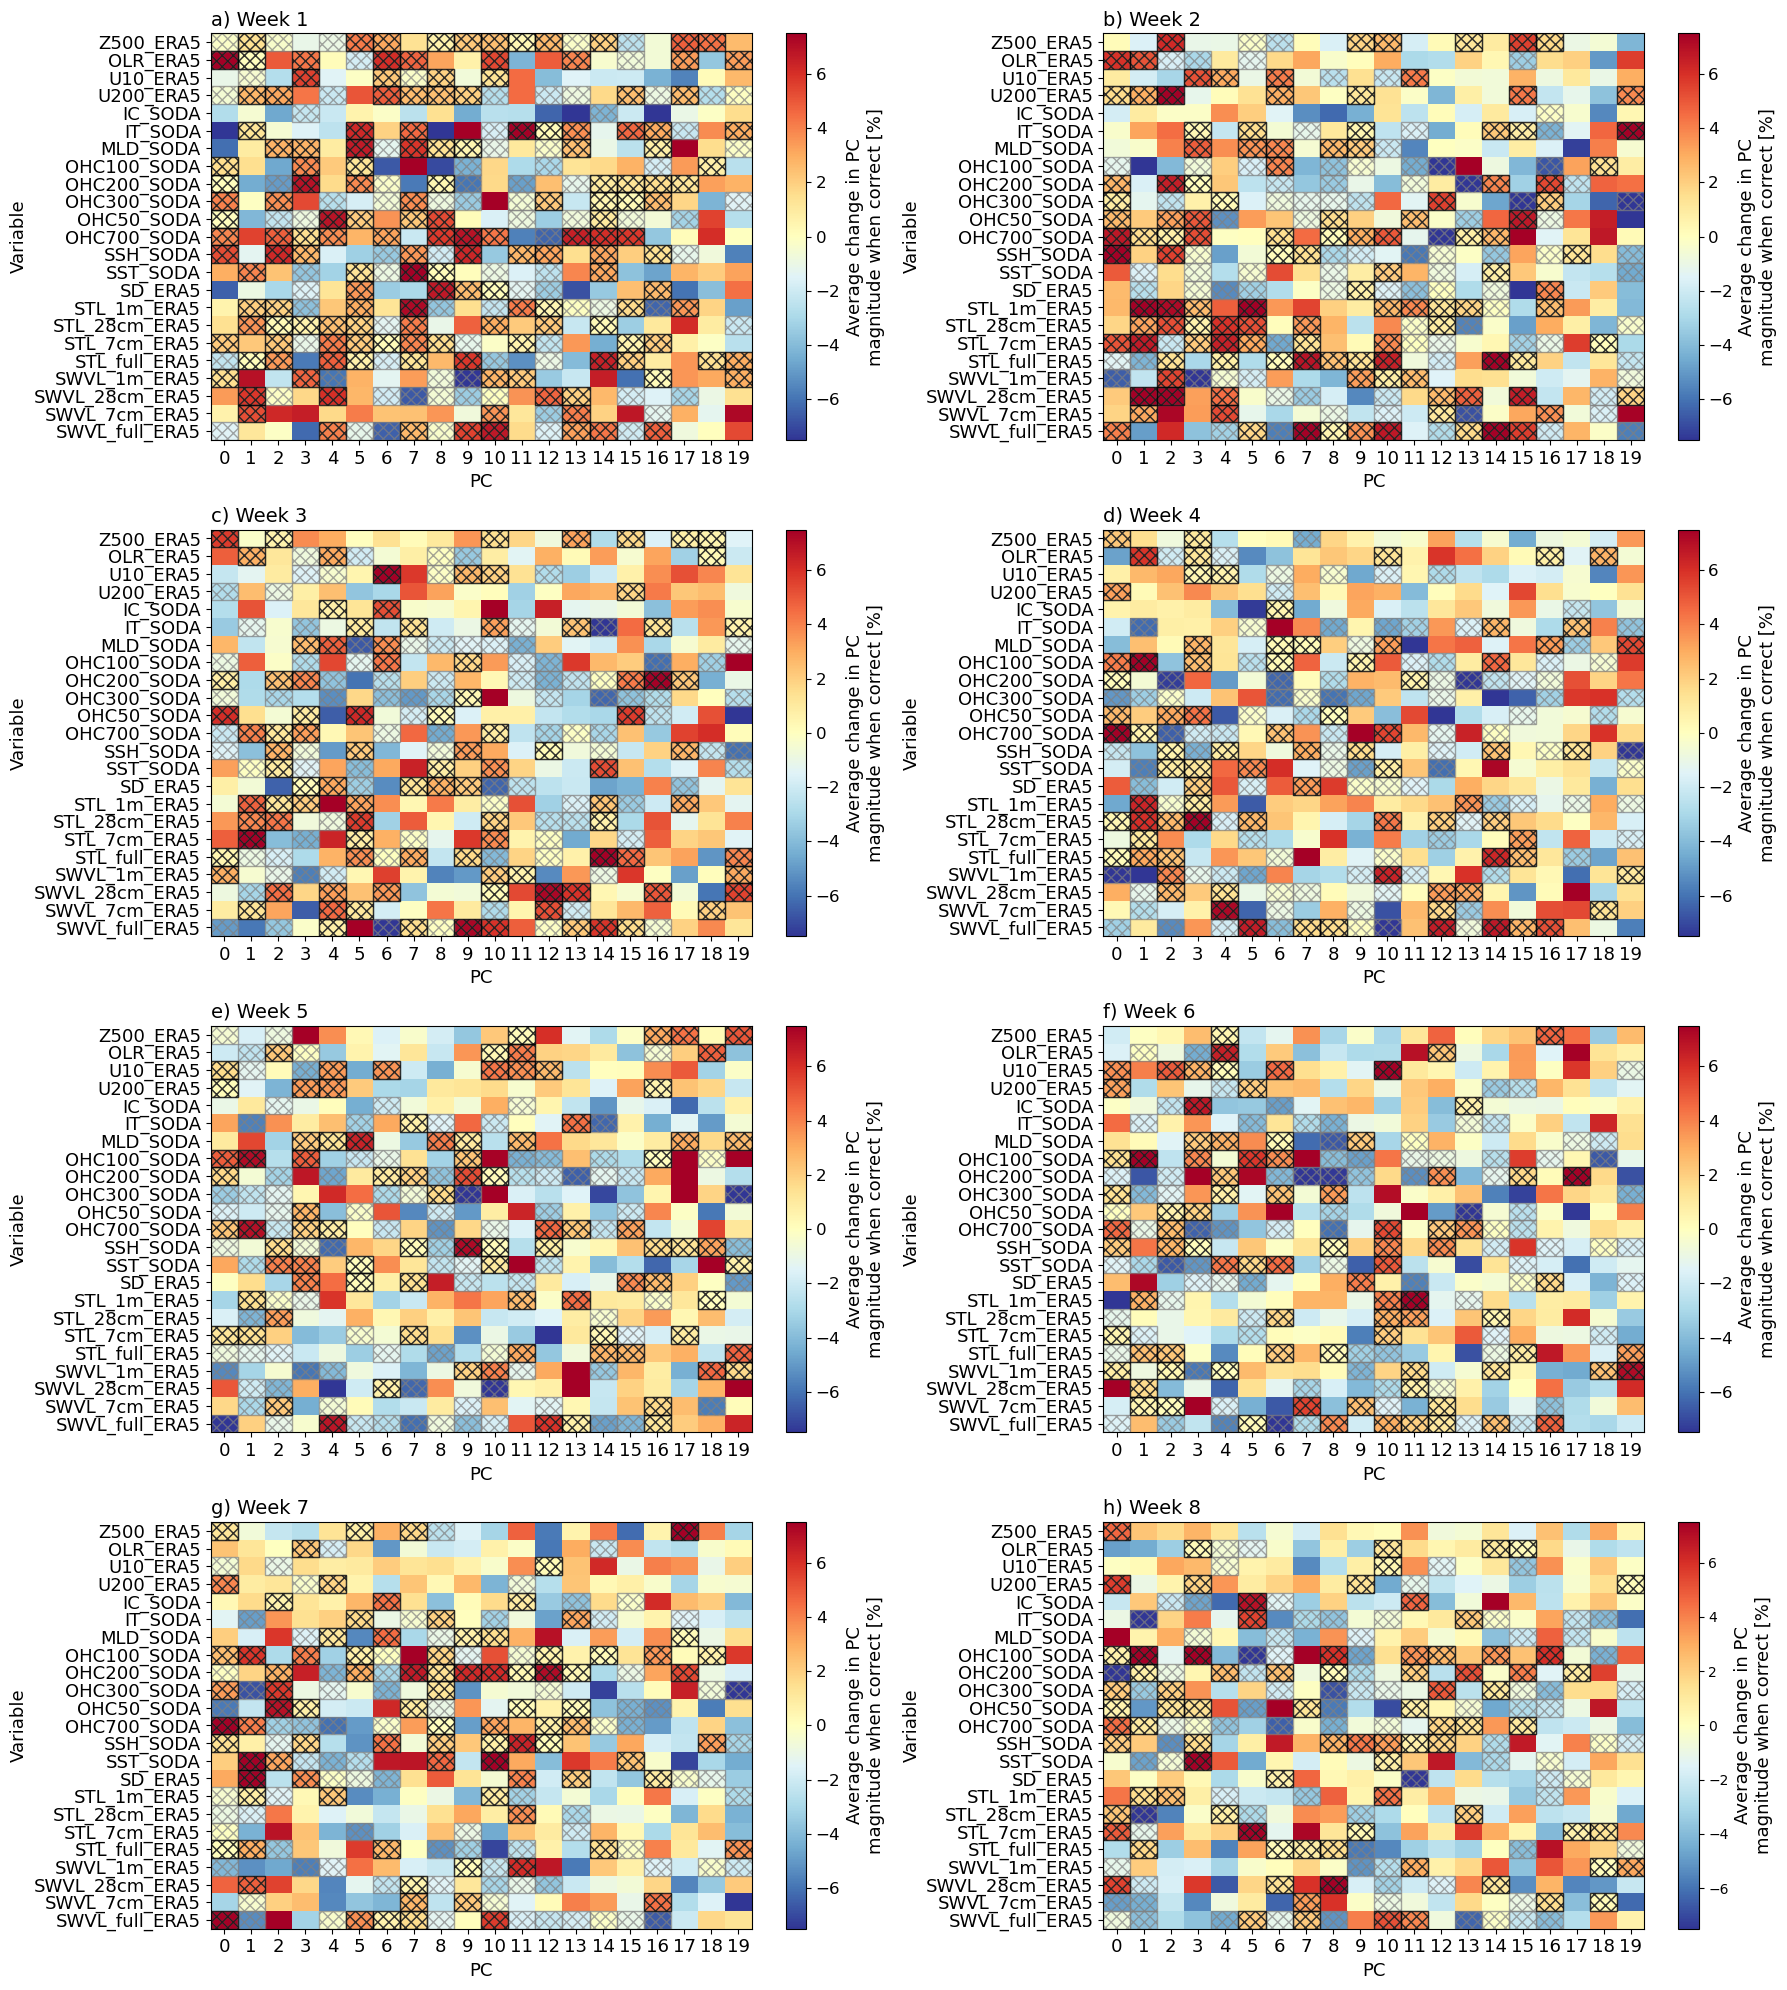

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import string

# Assuming list_vars, indices_ordered, pc_mean_when_accurate, significance_pcs, significance_filtered are defined
weeks = range(1, 9)  # Replace with your actual weeks range

# Create a figure and a set of subplots
fig, axs = plt.subplots(4, 2, figsize=(18, 20))  # 4 rows, 2 columns

# Flatten the axs array to easily iterate through
axs = axs.flatten()

for idx, week in enumerate(weeks):
    ax1 = axs[idx]
    cm = ax1.pcolormesh(np.arange(0, 20), np.array(list_vars)[indices_ordered],
                        pc_mean_when_accurate[week], vmin=-7.5, vmax=7.5, cmap='RdYlBu_r')

    # Plot the meshgrid for significance_pcs
    for i in range(len(np.array(list_vars)[indices_ordered])):
        for j in range(20):
            value = significance_pcs[week][i, j]
            if value == 1:
                hatch_pattern = 'xxx'
                ax1.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                            fill=False, hatch=hatch_pattern, color='gray', alpha=0.7))

    # Plot the meshgrid for significance_filtered
    for i in range(len(np.array(list_vars)[indices_ordered])):
        for j in range(20):
            value = significance_filtered[week][i, j]
            if value == 1:
                hatch_pattern = 'xxx'
                ax1.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                            fill=False, hatch=hatch_pattern, color='k', alpha=0.7))

    ax1.set_xticks(np.arange(0, 20))
    ax1.set_xticklabels(np.arange(0, 20), fontsize=13)
    ax1.set_yticks(np.arange(len(np.array(list_vars)[indices_ordered])))
    ax1.set_yticklabels(np.array(list_vars)[indices_ordered], fontsize=13)
    ax1.set_xlabel('PC', fontsize=13)
    ax1.set_ylabel('Variable', fontsize=13)
    ax1.invert_yaxis()
    
    abcd = list(string.ascii_lowercase)
    ax1.set_title(f'{abcd[week - 1]}) Week {week}', loc='left', fontsize=14)
    # Change colorbar ticks font size
    cbar.ax.yaxis.set_tick_params(labelsize=12)
    # Add colorbar
    cbar = fig.colorbar(cm, ax=ax1)
    cbar.set_label('Average change in PC\nmagnitude when correct [%]', fontsize=13)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the combined figure
plt.savefig('6_PCsHeatmap.pdf', bbox_inches='tight')

# Display the plot
plt.show()

In [20]:
array_hatching = np.stack([significance_filtered[1],
    significance_filtered[2],
    significance_filtered[3],
    significance_filtered[4],
    significance_filtered[5],
    significance_filtered[6],
    significance_filtered[7],
    significance_filtered[8]])

In [22]:
sum_weeks = np.sum(array_hatching,axis=0)
where_count = np.where(sum_weeks>=3)

In [23]:
for i in range(len(where_count[0])):
    print('****************')
    print(np.array(list_vars)[indices_ordered][where_count[0][i]],
         f'PC{where_count[1][i]}')
    hatching_temp = array_hatching[:,where_count[0][i],where_count[1][i]]
    print('weeks: ',np.where(hatching_temp==1)[0]+1)

****************
Z500_ERA5 PC0
weeks:  [3 4 7 8]
****************
Z500_ERA5 PC10
weeks:  [1 2 3]
****************
Z500_ERA5 PC16
weeks:  [2 5 6]
****************
Z500_ERA5 PC17
weeks:  [1 3 5 7]
****************
OLR_ERA5 PC1
weeks:  [1 2 3 4]
****************
OLR_ERA5 PC3
weeks:  [1 4 7 8]
****************
OLR_ERA5 PC10
weeks:  [1 4 5 8]
****************
OLR_ERA5 PC18
weeks:  [3 4 5]
****************
U10_ERA5 PC3
weeks:  [1 2 4 6]
****************
U10_ERA5 PC4
weeks:  [2 4 5 6]
****************
U10_ERA5 PC6
weeks:  [1 2 3 5 6]
****************
U10_ERA5 PC10
weeks:  [1 3 5 6 8]
****************
U200_ERA5 PC0
weeks:  [2 4 5 6 7 8]
****************
U200_ERA5 PC9
weeks:  [1 2 8]
****************
U200_ERA5 PC15
weeks:  [1 2 3]
****************
IC_SODA PC6
weeks:  [3 4 7]
****************
IT_SODA PC5
weeks:  [1 2 3 7 8]
****************
IT_SODA PC7
weeks:  [1 3 5]
****************
IT_SODA PC13
weeks:  [1 3 5 7 8]
****************
IT_SODA PC19
weeks:  [1 2 3]
****************
MLD_SODA PC3
wee